# AtlasOT Minimal Tutorial: RNA → ATAC Label Transfer (MI RZ_BZ_P3)

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import muon as mu
import torch
import atlasot as aot

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

## 1. Load MI Data (RZ_BZ_P3)

In [2]:
import os, urllib.request
from tqdm.auto import tqdm

DATA_URL = "https://github.com/CostaLab/AtlasOT/releases/download/demo-data/demo_RZ_BZ_P3.h5mu"
DATA_PATH = "demo_RZ_BZ_P3.h5mu"

if not os.path.exists(DATA_PATH):
    # download to a .part file first, so an interrupted run cannot leave a
    # truncated file behind that the os.path.exists() check would then accept
    tmp = DATA_PATH + ".part"
    with tqdm(unit="B", unit_scale=True, unit_divisor=1024, desc=DATA_PATH) as bar:
        def _hook(count, block_size, total_size):
            if total_size > 0:
                bar.total = total_size
                bar.update(min(count * block_size, total_size) - bar.n)
        urllib.request.urlretrieve(DATA_URL, tmp, reporthook=_hook)
    os.replace(tmp, DATA_PATH)

In [3]:
m = mu.read_h5mu(DATA_PATH)
rna = m['gene_expression'].copy()
atac = m['peaks'].copy()
atac_gene = m['gene_activity'].copy()

print(f"RNA: {rna.shape}, ATAC peaks: {atac.shape}, ATAC gene: {atac_gene.shape}")
print(f"RNA cell types: {rna.obs['cell_type'].value_counts().to_dict()}")

RNA: (6851, 29126), ATAC peaks: (2027, 521942), ATAC gene: (2027, 24919)
RNA cell types: {'CM': 2964, 'Fib': 2272, 'Myeloid': 633, 'Endo': 529, 'Pericyte': 179, 'Lymphoid': 99, 'vSMCs': 59, 'Neuronal': 47, 'prolif': 47, 'Adipo': 11, 'Mast': 11}


## 2. Preprocessing & Dimensionality Reduction (using AtlasOT functions)

ATAC peaks are reduced with **scOpen**, which produces `obsm['scopen']` — the
embedding used to build the ATAC cost matrix in step 4. This is the slowest
step of the notebook (several minutes on ~500k peaks).


In [4]:
rna = aot.preprocess_rna(rna, save_counts=True)
rna = aot.reduction_rna(rna)

atac = aot.preprocess_atac_peaks(atac, save_counts=True)
atac = aot.reduction_atac_peaks(atac, reduction='scopen')  # writes obsm['scopen'], It will take a long time.

atac_gene = aot.preprocess_atac_genes(atac_gene, save_counts=True)
atac_gene = aot.reduction_atac_genes(atac_gene)

print("Preprocessing done.")
print(f"RNA obsm keys: {list(rna.obsm.keys())}")
print(f"ATAC obsm keys: {list(atac.obsm.keys())}")
print(f"ATAC gene obsm keys: {list(atac_gene.obsm.keys())}")

09/07/2026 12:36:43, running tf-idf transformation...
09/07/2026 12:37:54, iteration:  0, violation:  1.00000000
09/07/2026 12:37:56, iteration:  1, violation:  0.25836914
09/07/2026 12:37:57, iteration:  2, violation:  0.14981264
09/07/2026 12:37:59, iteration:  3, violation:  0.07268700
09/07/2026 12:38:00, iteration:  4, violation:  0.03641188
09/07/2026 12:38:02, iteration:  5, violation:  0.02752818
09/07/2026 12:38:03, iteration:  6, violation:  0.02384839
09/07/2026 12:38:04, iteration:  7, violation:  0.02054016
09/07/2026 12:38:06, iteration:  8, violation:  0.01777053
09/07/2026 12:38:07, iteration:  9, violation:  0.01553438
09/07/2026 12:38:09, iteration:  10, violation:  0.01374123
09/07/2026 12:38:10, iteration:  11, violation:  0.01229566
09/07/2026 12:38:12, iteration:  12, violation:  0.01112679
09/07/2026 12:38:13, iteration:  13, violation:  0.01017733
09/07/2026 12:38:15, iteration:  14, violation:  0.00940013
09/07/2026 12:38:16, iteration:  15, violation:  0.00875

## 3. Shared Space — Common-Gene PCA

Take genes present in both RNA and ATAC-gene-activity, scale, fit PCA on RNA, and project both modalities into the same PC space:

$$\text{shareSpace}_{\text{RNA}}, \text{shareSpace}_{\text{ATAC}} = \text{PCA}_{\text{common genes}}(\text{RNA}, \text{ATAC})$$

In [5]:
common_genes = list(set(rna.var['features']).intersection(atac_gene.var['features']))
print(f"Common genes: {len(common_genes)}")

rna.obsm['shareSpace'], atac.obsm['shareSpace'] = aot.find_shared_space(
    common_genes, rna, atac_gene
)
print(f"shareSpace RNA: {rna.obsm['shareSpace'].shape}, ATAC: {atac.obsm['shareSpace'].shape}")

Common genes: 19204
shareSpace RNA: (6851, 10), ATAC: (2027, 10)


## 4. Cost Matrices

- $M$ — **cross-modality distance**: cosine distance between shared-space embeddings. $M[i,j]$ is the dissimilarity between ATAC cell $i$ and RNA cell $j$ in the shared latent space.
- $C_{\text{RNA}}$, $C_{\text{ATAC}}$ — **intra-modality cost**: geodesic (shortest-path) distance on a k-NN graph built from modality-specific embeddings. Captures local neighborhood structure within each modality.

$$M = 1 - \frac{\text{shareSpace}_{\text{ATAC}} \cdot \text{shareSpace}_{\text{RNA}}^\top}{\|\text{shareSpace}_{\text{ATAC}}\| \;\|\text{shareSpace}_{\text{RNA}}\|}$$

$$C = \text{shortest\_path}\big(\text{kNN}(X,\;k=30)\big)$$

In [6]:
M = aot.cosine_distance_tensor(atac.obsm['shareSpace'], rna.obsm['shareSpace']).to(device)

rna.obsp['cost_matrix'] = aot.compute_geodesic_distance(rna.obsm['RNA_pca_l2_norm'], k=30, metric='cosine')
atac.obsp['cost_matrix'] = aot.compute_geodesic_distance(atac.obsm['scopen'], k=30, metric='cosine')

print(f"M shape: {M.shape}")
print(f"RNA cost: {rna.obsp['cost_matrix'].shape}, ATAC cost: {atac.obsp['cost_matrix'].shape}")

M shape: torch.Size([2027, 6851])
RNA cost: (6851, 6851), ATAC cost: (2027, 2027)


## 5. Transport Plan π — FUGW Optimization

Solve the Fused Unbalanced Gromov-Wasserstein problem:

$$\min_{\pi}\; (1-\alpha) \langle M, \pi \rangle + \alpha\,GW(C_{\text{src}}, C_{\text{tgt}}, \pi) + \rho \cdot KL(\pi \mathbf{1}, \mathbf{a}) + \rho \cdot KL(\pi^\top \mathbf{1}, \mathbf{b}) + \varepsilon \cdot H(\pi)$$

- $\alpha$: weights geometry preservation (GW) against feature matching (M). $\alpha \rightarrow 0$ trusts the shared space (M) only; $\alpha \rightarrow 1$ trusts the intra-modality geometries only.
- $\rho$: unbalancedness — allows marginal mismatch (useful for imbalanced data).
- $\varepsilon$: entropic regularization — smaller = sharper transport.

**Direction**: $source=ATAC$, $target=RNA$ → $\pi$ has shape $(n_{\text{ATAC}}, n_{\text{RNA}})$.

In [7]:
pi = aot.scFUGW_RNA_Spatial_with_cost(
    target=rna,
    source=atac,
    target_cost='cost_matrix',
    source_cost='cost_matrix',
    M=M,
    alpha=0.9,
    rho=1.1,
    eps=1e-6,
    random_seed=3407,
)

pi = pi.cpu().numpy()
print(f"π shape: {pi.shape}, sum: {pi.sum():.2f}")

[12:43:45] Validation data for feature maps is not provided. Using training data instead.              ]8;id=5100147;file:///beegfs/home/kpeng/miniconda3/envs/atlasot/lib/python3.10/site-packages/fugw/mappings/dense.py\dense.py]8;;\:]8;id=5100148;file:///beegfs/home/kpeng/miniconda3/envs/atlasot/lib/python3.10/site-packages/fugw/mappings/dense.py#205\205]8;;\

           Validation data for anatomical kernels is not provided. Using training data instead.        ]8;id=5100154;file:///beegfs/home/kpeng/miniconda3/envs/atlasot/lib/python3.10/site-packages/fugw/mappings/dense.py\dense.py]8;;\:]8;id=5100155;file:///beegfs/home/kpeng/miniconda3/envs/atlasot/lib/python3.10/site-packages/fugw/mappings/dense.py#232\232]8;;\

Output()

Output()

[12:43:56] BCD step 1/10   FUGW loss:      3.3538105487823486      Validation loss:                    ]8;id=5100162;file:///beegfs/home/kpeng/miniconda3/envs/atlasot/lib/python3.10/site-packages/fugw/solvers/dense.py\dense.py]8;;\:]8;id=5100163;file:///beegfs/home/kpeng/miniconda3/envs/atlasot/lib/python3.10/site-packages/fugw/solvers/dense.py#580\580]8;;\
           3.3538105487823486                                                                                      

...

[12:45:24] BCD step 9/10   FUGW loss:      0.38737261295318604     Validation loss:                    ]8;id=5100210;file:///beegfs/home/kpeng/miniconda3/envs/atlasot/lib/python3.10/site-packages/fugw/solvers/dense.py\dense.py]8;;\:]8;id=5100211;file:///beegfs/home/kpeng/miniconda3/envs/atlasot/lib/python3.10/site-packages/fugw/solvers/dense.py#580\580]8;;\
           0.38737261295318604                                                                                     

Output()

Output()

[12:45:35] BCD step 10/10  FUGW loss:      0.35144132375717163     Validation loss:                    ]8;id=5100216;file:///beegfs/home/kpeng/miniconda3/envs/atlasot/lib/python3.10/site-packages/fugw/solvers/dense.py\dense.py]8;;\:]8;id=5100217;file:///beegfs/home/kpeng/miniconda3/envs/atlasot/lib/python3.10/site-packages/fugw/solvers/dense.py#580\580]8;;\
           0.35144132375717163                                                                                     

π shape: (2027, 6851), sum: 0.97


## 6. Label Transfer

Use the transport plan to transfer labels from target (RNA) to source (ATAC):

$$\text{probs}_{\text{ATAC}} = \pi \times \text{onehot}(\text{labels}_{\text{RNA}})$$

$$\text{pred}_{\text{ATAC}} = \arg\max(\text{probs}_{\text{ATAC}})$$

In [8]:
pred_labels = aot.ot_label_transfer(pi, rna.obs['cell_type'])

true_labels = atac.obs['cell_type'].values.astype(str)
acc = np.mean(pred_labels == true_labels)
print(f"Label Transfer Accuracy: {acc:.4f}")
print(f"\nPredicted distribution:\n{pd.Series(pred_labels).value_counts()}")

Label Transfer Accuracy: 0.9630

Predicted distribution:
CM          1231
Fib          335
Myeloid      209
Endo         125
Pericyte      61
Lymphoid      35
vSMCs         14
prolif         7
Neuronal       4
Adipo          3
Mast           3
Name: count, dtype: int64


## 7. Visualization — Joint UMAP

Map ATAC cells into RNA PCA space via the transport plan, then run UMAP on the combined embeddings:

$$\text{ATAC}_{\text{mapped}} = \pi \cdot \text{RNA}_{pca}\;/\;\sum\pi$$

Combined shape: (8878, 501465)
Modality counts: {'RNA': 6851, 'ATAC': 2027}
UMAP done, coords shape: (8878, 2)


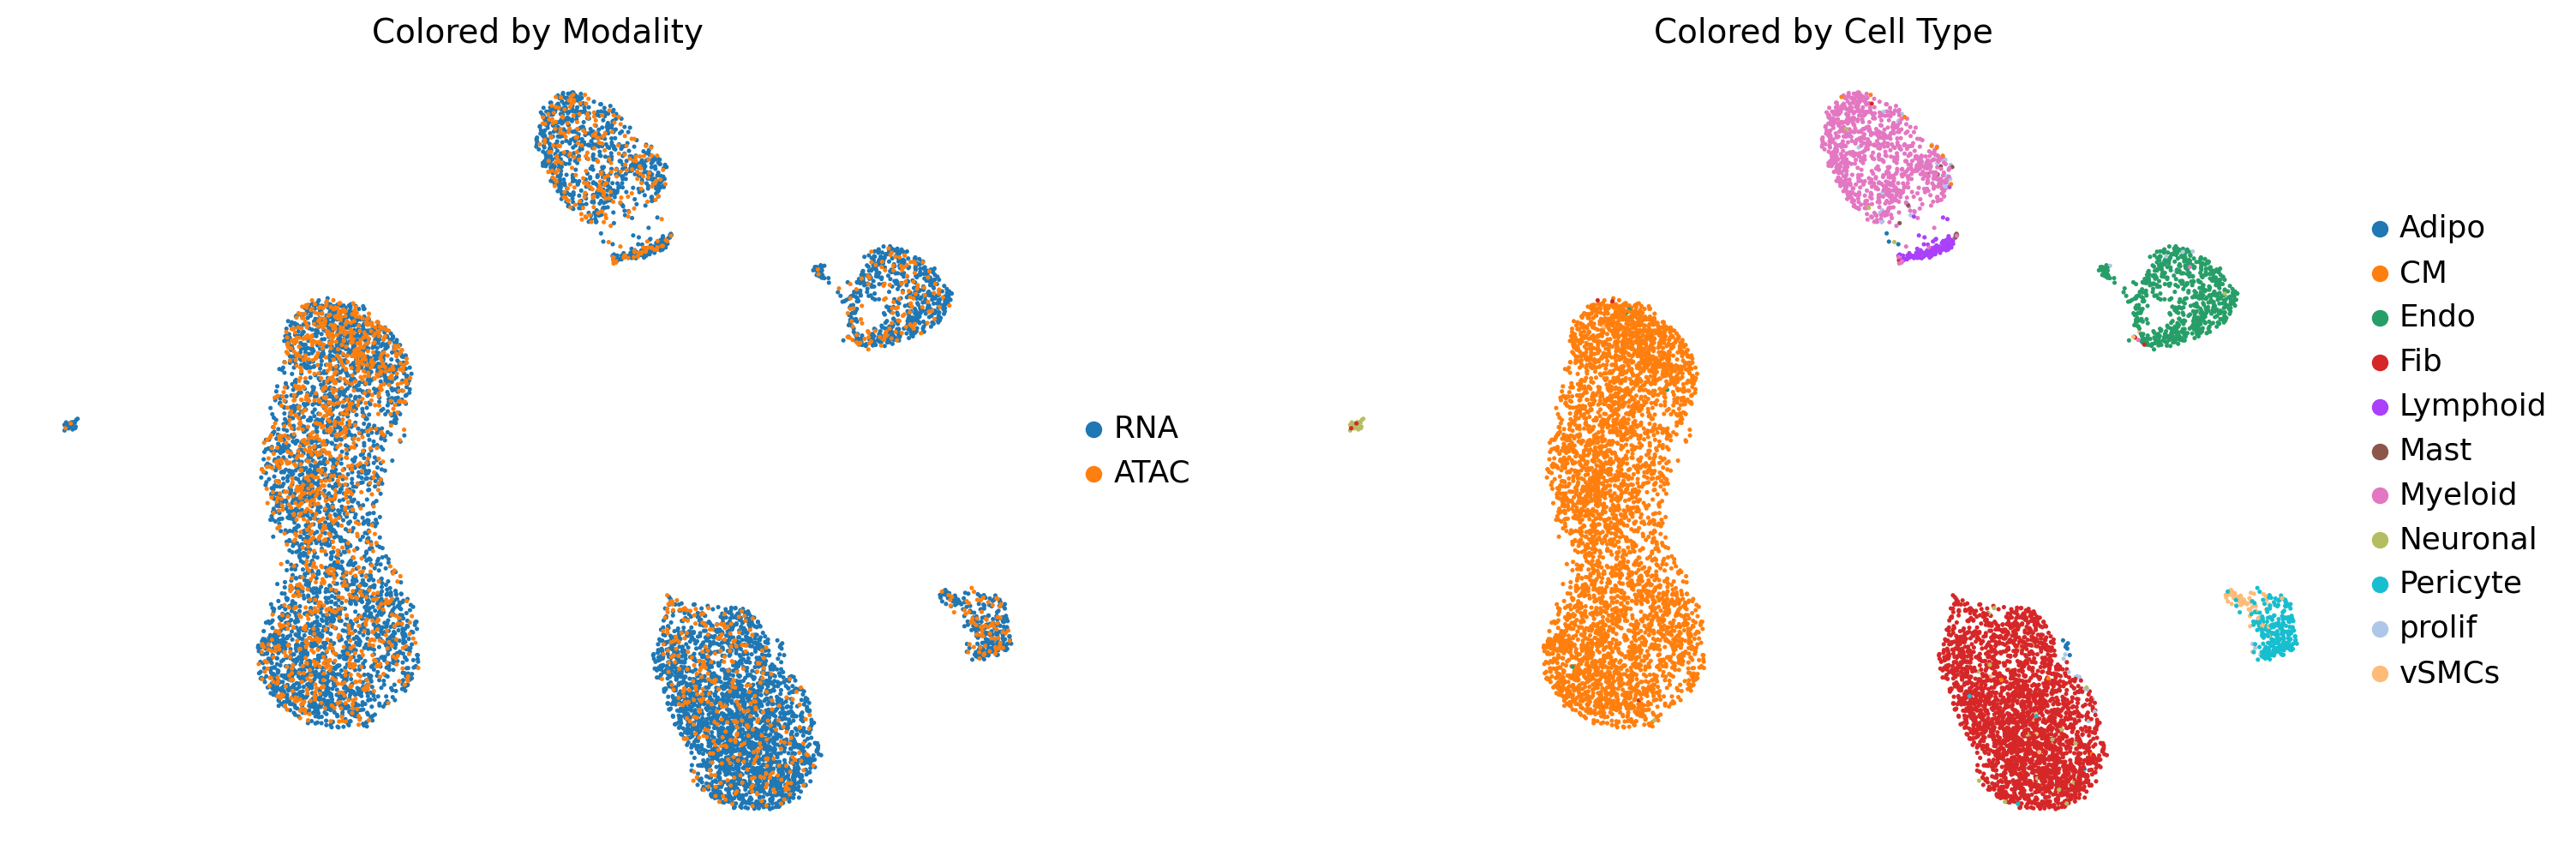

In [9]:
# Ensure inline rendering (VS Code Jupyter may need this per-cell)
%matplotlib inline
import anndata as ad

# Map ATAC to RNA PCA space
atac_mapped = aot.map_to_target(pi, rna.obsm['RNA_pca_l2_norm'])

# Build joint AnnData — P002 pattern: ad.concat + obsm
combined = ad.concat(
    [rna, atac],
    join="outer",
    label="modality",
    keys=["RNA", "ATAC"],
)
combined.obsm["X_integrated"] = np.concatenate(
    [rna.obsm['RNA_pca_l2_norm'], atac_mapped], axis=0
)
print(f"Combined shape: {combined.shape}")
print(f"Modality counts: {combined.obs['modality'].value_counts().to_dict()}")

sc.pp.neighbors(combined, n_neighbors=30, use_rep="X_integrated")
sc.tl.umap(combined)
print(f"UMAP done, coords shape: {combined.obsm['X_umap'].shape}")

sc.set_figure_params(dpi=100, frameon=False)

# Side-by-side: Modality (left) + Cell Type (right)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sc.pl.umap(combined, color=["modality"], title="Colored by Modality",
           palette={"RNA": "#1f77b4", "ATAC": "#ff7f0e"}, ax=ax1, show=False)
sc.pl.umap(combined, color="cell_type", title="Colored by Cell Type",
           ax=ax2, show=False)
plt.tight_layout(pad=3.0)
plt.show()